In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgboost
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,train_test_split,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,mean_squared_error,f1_score,recall_score,precision_score


In [7]:
df = pd.read_csv('crypto_top1000_dataset.csv')

In [8]:
df.head()

,id,symbol,name,market_cap_rank,current_price,market_cap,fully_diluted_valuation,total_volume,high_24h,low_24h,...,price_change_percentage_24h,price_change_percentage_1h,price_change_percentage_7d,price_change_percentage_30d,price_change_percentage_1y,market_cap_change_24h,market_cap_change_percentage_24h,last_updated,image,supply_utilization
0,bitcoin,BTC,Bitcoin,1,92551.00,1849586398531,1.849586e+12,8.165691e+10,93929.00,90837.00,...,0.66511,-0.473153,5.391199,-13.158877,-2.776377,1.411594e+10,0.76906,2025-12-03T18:57:01.835Z,https://coin-images.coingecko.com/coins/images...,95.034210
1,ethereum,ETH,Ethereum,2,3114.18,377137085161,3.771371e+11,2.534897e+10,3139.77,2976.94,...,3.29234,-0.530166,5.687871,-13.815571,-12.423514,1.290545e+10,3.54320,2025-12-03T18:57:03.636Z,https://coin-images.coingecko.com/coins/images...,0.000000
2,tether,USDT,Tether,3,1.00,184744825283,1.902134e+11,1.017624e+11,1.00,1.00,...,0.00099,-0.004542,0.043571,0.030966,0.013444,1.066272e+08,0.05775,2025-12-03T18:57:02.158Z,https://coin-images.coingecko.com/coins/images...,0.000000
3,ripple,XRP,XRP,4,2.17,131451182003,2.178500e+11,4.038903e+09,2.21,2.14,...,0.01637,-0.497115,-0.706636,-8.403034,-13.724117,3.666673e+08,0.27972,2025-12-03T18:57:00.544Z,https://coin-images.coingecko.com/coins/images...,60.331635
4,binancecoin,BNB,BNB,5,902.22,124271801383,1.242718e+11,2.001782e+09,908.27,873.60,...,2.40889,-0.549929,3.466731,-9.351678,39.560349,2.885939e+09,2.37749,2025-12-03T18:57:01.669Z,https://coin-images.coingecko.com/coins/images...,68.868065


In [9]:
df.describe()

,market_cap_rank,current_price,market_cap,fully_diluted_valuation,total_volume,high_24h,low_24h,circulating_supply,total_supply,max_supply,...,atl_change_percentage,price_change_24h,price_change_percentage_24h,price_change_percentage_1h,price_change_percentage_7d,price_change_percentage_30d,price_change_percentage_1y,market_cap_change_24h,market_cap_change_percentage_24h,supply_utilization
count,1000.000000,1.000000e+03,1.000000e+03,9.980000e+02,1.000000e+03,9.870000e+02,9.870000e+02,1.000000e+03,9.980000e+02,5.650000e+02,...,1.000000e+03,987.000000,987.000000,980.000000,995.000000,978.000000,677.000000,9.860000e+02,986.000000,1000.000000
mean,500.514000,3.020196e+03,3.382915e+09,5.688250e+09,2.693727e+08,3.085377e+03,2.975851e+03,1.856249e+14,4.335387e+14,7.658999e+14,...,1.447517e+32,40.806696,0.898115,-0.086534,273.188205,242.640769,89.565864,4.067557e+07,32.768743,34.619589
std,288.842694,1.577453e+04,6.032522e+10,8.648060e+10,4.221592e+09,1.607505e+04,1.551608e+04,5.513662e+15,1.329493e+16,1.766923e+16,...,4.577452e+33,229.194971,6.384397,1.224800,8582.654705,7677.341273,2072.411310,6.199682e+08,995.592805,38.952744
min,1.000000,7.392680e-10,2.579177e+07,2.579177e+07,0.000000e+00,7.552700e-10,6.990220e-10,2.890172e+02,0.000000e+00,8.888000e+03,...,0.000000e+00,-3.942972,-37.457900,-8.695587,-64.142203,-95.802529,-99.981755,-3.840779e+08,-36.528110,0.000000
25%,250.750000,5.445100e-02,4.126963e+07,5.596051e+07,3.811775e+05,5.612500e-02,5.209250e-02,4.159729e+07,4.802165e+07,4.000000e+08,...,1.850787e+01,-0.000496,-0.733705,-0.441268,-3.081141,-17.980009,-79.229659,-5.840339e+05,-0.817982,0.000000
50%,500.500000,4.194065e-01,7.931666e+07,1.302084e+08,4.649918e+06,4.204880e-01,3.944960e-01,3.349151e+08,9.541714e+08,1.000000e+09,...,9.391917e+01,0.000191,0.210030,-0.122374,0.064689,-10.840300,-55.124787,3.379245e+05,0.387745,18.840967
75%,750.250000,1.965000e+00,2.440914e+08,3.908282e+08,1.953813e+07,1.840000e+00,1.770000e+00,1.709020e+09,2.662840e+09,1.000000e+10,...,5.556947e+02,0.014306,2.432890,0.058779,3.558208,0.028362,-1.778249,3.088509e+06,2.576065,73.009876
max,1002.000000,9.816900e+04,1.849586e+12,1.950679e+12,1.017624e+11,9.991500e+04,9.501400e+04,1.743388e+17,4.200000e+17,4.200000e+17,...,1.447517e+35,2480.660000,111.765830,21.264514,270728.629225,240068.374988,50754.529716,1.411594e+10,31262.617420,100.000000


In [12]:
df['volume_to_marketcap'] = df['total_volume'] / df['market_cap']

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                1000 non-null   str    
 1   symbol                            1000 non-null   str    
 2   name                              1000 non-null   str    
 3   market_cap_rank                   1000 non-null   int64  
 4   current_price                     1000 non-null   float64
 5   market_cap                        1000 non-null   int64  
 6   fully_diluted_valuation           998 non-null    float64
 7   total_volume                      1000 non-null   float64
 8   high_24h                          987 non-null    float64
 9   low_24h                           987 non-null    float64
 10  circulating_supply                1000 non-null   float64
 11  total_supply                      998 non-null    float64
 12  max_supply        

In [14]:
df.columns.tolist()

['id',
 'symbol',
 'name',
 'market_cap_rank',
 'current_price',
 'market_cap',
 'fully_diluted_valuation',
 'total_volume',
 'high_24h',
 'low_24h',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'ath',
 'ath_change_percentage',
 'ath_date',
 'atl',
 'atl_change_percentage',
 'atl_date',
 'price_change_24h',
 'price_change_percentage_24h',
 'price_change_percentage_1h',
 'price_change_percentage_7d',
 'price_change_percentage_30d',
 'price_change_percentage_1y',
 'market_cap_change_24h',
 'market_cap_change_percentage_24h',
 'last_updated',
 'image',
 'supply_utilization',
 'volume_to_marketcap']

In [16]:
df.head()

,id,symbol,name,market_cap_rank,current_price,market_cap,fully_diluted_valuation,total_volume,high_24h,low_24h,...,price_change_percentage_1h,price_change_percentage_7d,price_change_percentage_30d,price_change_percentage_1y,market_cap_change_24h,market_cap_change_percentage_24h,last_updated,image,supply_utilization,volume_to_marketcap
0,bitcoin,BTC,Bitcoin,1,92551.00,1849586398531,1.849586e+12,8.165691e+10,93929.00,90837.00,...,-0.473153,5.391199,-13.158877,-2.776377,1.411594e+10,0.76906,2025-12-03T18:57:01.835Z,https://coin-images.coingecko.com/coins/images...,95.034210,0.044149
1,ethereum,ETH,Ethereum,2,3114.18,377137085161,3.771371e+11,2.534897e+10,3139.77,2976.94,...,-0.530166,5.687871,-13.815571,-12.423514,1.290545e+10,3.54320,2025-12-03T18:57:03.636Z,https://coin-images.coingecko.com/coins/images...,0.000000,0.067214
2,tether,USDT,Tether,3,1.00,184744825283,1.902134e+11,1.017624e+11,1.00,1.00,...,-0.004542,0.043571,0.030966,0.013444,1.066272e+08,0.05775,2025-12-03T18:57:02.158Z,https://coin-images.coingecko.com/coins/images...,0.000000,0.550827
3,ripple,XRP,XRP,4,2.17,131451182003,2.178500e+11,4.038903e+09,2.21,2.14,...,-0.497115,-0.706636,-8.403034,-13.724117,3.666673e+08,0.27972,2025-12-03T18:57:00.544Z,https://coin-images.coingecko.com/coins/images...,60.331635,0.030725
4,binancecoin,BNB,BNB,5,902.22,124271801383,1.242718e+11,2.001782e+09,908.27,873.60,...,-0.549929,3.466731,-9.351678,39.560349,2.885939e+09,2.37749,2025-12-03T18:57:01.669Z,https://coin-images.coingecko.com/coins/images...,68.868065,0.016108


In [17]:
y = np.where(df['price_change_percentage_1y'] > 0,1,0)

In [30]:
X = df.drop(columns=[
    'price_change_percentage_1y', 'name', 'symbol', 'id', 'image', 
    'ath_date', 'atl_date', 'last_updated',
    'current_price', 'high_24h', 'low_24h', 'price_change_24h', 'atl',
    'fully_diluted_valuation', 'market_cap_change_24h', 'market_cap_change_percentage_24h',
    'total_supply', 'max_supply','ath'
])

In [24]:
print(y)

[0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0
 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 

In [31]:
print(X)

     market_cap_rank     market_cap  total_volume  circulating_supply  \
0                  1  1849586398531  8.165691e+10        1.995718e+07   
1                  2   377137085161  2.534897e+10        1.206954e+08   
2                  3   184744825283  1.017624e+11        1.846881e+11   
3                  4   131451182003  4.038903e+09        6.033164e+10   
4                  5   124271801383  2.001782e+09        1.377361e+08   
..               ...            ...           ...                 ...   
995              999       25835208  4.341250e+03        8.207440e+07   
996             1000       25832950  5.328143e+06        2.508233e+06   
997             1001       25816526  7.819600e+04        2.211393e+07   
998             1002       25815570  1.230519e+07        2.582835e+07   
999              997       25791773  6.185000e+04        3.491824e+06   

     ath_change_percentage  atl_change_percentage  \
0                -26.16251           1.371889e+05   
1                

In [32]:
print(list(X.columns))

['market_cap_rank', 'market_cap', 'total_volume', 'circulating_supply', 'ath_change_percentage', 'atl_change_percentage', 'price_change_percentage_24h', 'price_change_percentage_1h', 'price_change_percentage_7d', 'price_change_percentage_30d', 'supply_utilization', 'volume_to_marketcap']


In [34]:
#TRAIN/TEST/SPLIT
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [35]:
print(X_train.shape)

(800, 12)


In [36]:
print(X_test.shape)

(200, 12)


In [54]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
     ('imputer', SimpleImputer(strategy='median')),
    ('classifer',LogisticRegression(class_weight='balanced',random_state=42))
])

In [55]:
cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

In [56]:
cv_scores = cross_val_score(pipeline, X_train, y_train,cv=cv, scoring='accuracy')

In [57]:
print(f"CV Mean Accuracy: {cv_scores.mean():.2f}")

CV Mean Accuracy: 0.65


In [59]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['market_cap_rank','market_cap','total_volume',..., 'price_change_percentage_30d','supply_utilization','volume_to_marketcap']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [60]:
final_preds = pipeline.predict(X_test)

In [50]:
print(accuracy_score(y_test,final_preds))

0.865


In [61]:
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80       173
           1       0.23      0.56      0.33        27

    accuracy                           0.69       200
   macro avg       0.57      0.63      0.56       200
weighted avg       0.82      0.69      0.73       200



In [65]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(class_weight='balanced_subsample', random_state=42))
])

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
cv_scores = cross_val_score(rf_pipeline, X_train,y_train,cv=cv,scoring='f1')

In [68]:
print(f'cv mean F1 SCORE: {cv_scores.mean()}')

cv mean F1 SCORE: 0.1895


In [74]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['market_cap_rank','market_cap','total_volume',..., 'price_change_percentage_30d','supply_utilization','volume_to_marketcap']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace 

In [75]:
rf_preds = rf_pipeline.predict(X_test)

In [76]:
print(classification_report(y_test,rf_preds))

              precision    recall  f1-score   support

           0       0.87      0.99      0.93       173
           1       0.50      0.04      0.07        27

    accuracy                           0.86       200
   macro avg       0.68      0.52      0.50       200
weighted avg       0.82      0.86      0.81       200



In [78]:
#  IMBALANCE RATIO

num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
imbalance_ratio = num_neg/num_pos
print(imbalance_ratio)

6.2727272727272725


In [93]:
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', XGBClassifier(
        scale_pos_weight = imbalance_ratio,
        random_state = 42,
        eval_metrics = 'logloss'
    ))
])

In [82]:
xgb_pipeline.fit(X_train,y_train)

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:29:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['market_cap_rank','market_cap','total_volume',..., 'price_change_percentage_30d','supply_utilization','volume_to_marketcap']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace 

In [83]:
xgb_preds = xgb_pipeline.predict(X_test)

In [84]:
print(classification_report(y_test,xgb_preds))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       173
           1       0.50      0.33      0.40        27

    accuracy                           0.86       200
   macro avg       0.70      0.64      0.66       200
weighted avg       0.85      0.86      0.85       200



In [85]:
probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]

In [86]:
strict_preds = (probabilities >= 0.70).astype(int)

In [87]:
print("XGBoost Strict Threshold (70% Confidence) Results:")
print(classification_report(y_test, strict_preds))

XGBoost Strict Threshold (70% Confidence) Results:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       173
           1       0.57      0.30      0.39        27

    accuracy                           0.88       200
   macro avg       0.73      0.63      0.66       200
weighted avg       0.85      0.88      0.86       200



In [95]:
param_grid = {
    'classifier__max_depth':[3, 4, 5],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [50, 100, 150]
}


In [96]:
grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=cv, scoring='f1',n_jobs=1)

In [97]:
grid_search.fit(X_train, y_train)

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:43:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:43:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:43:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:43:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bs

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [98]:
print(grid_search.best_params_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


In [99]:
best_model = grid_search.best_estimator_
probabilities = best_model.predict_proba(X_test)[:,1]
strict_preds = (probabilities >= 0.70).astype(int)

In [100]:
print("Tuned XGBoost Strict Threshold (70% Confidence) Results:")
print(classification_report(y_test, strict_preds))

Tuned XGBoost Strict Threshold (70% Confidence) Results:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       173
           1       0.60      0.33      0.43        27

    accuracy                           0.88       200
   macro avg       0.75      0.65      0.68       200
weighted avg       0.86      0.88      0.86       200



In [101]:
print(grid_search.best_params_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


In [103]:
best_xgb = grid_search.best_estimator_.named_steps['classifier']

In [104]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=True) 

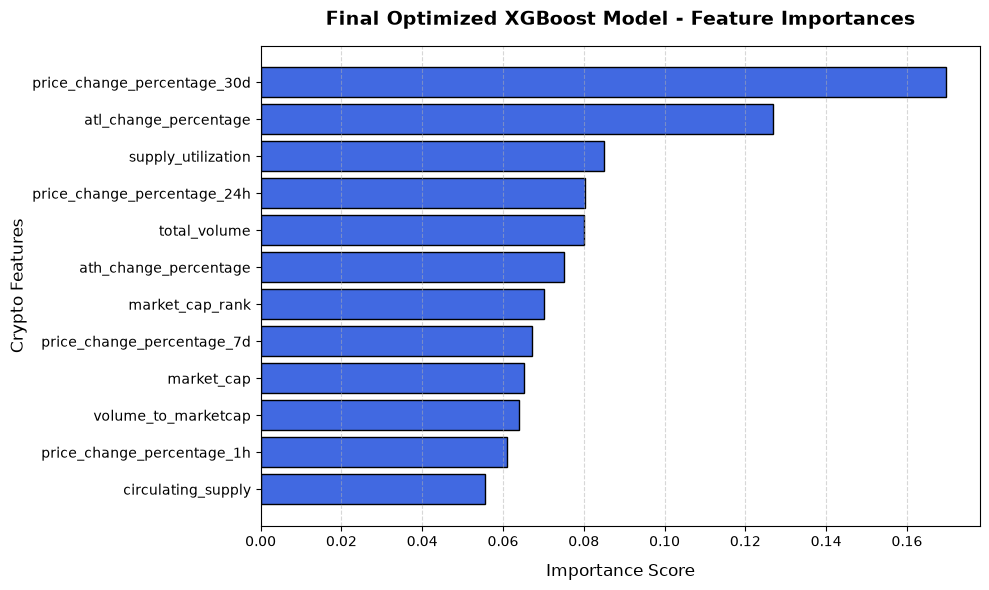

In [107]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue', edgecolor='black')


plt.title('Final Optimized XGBoost Model - Feature Importances', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Crypto Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()